# Beam Convolution 

IDEA: descrive the beam with a basis of functions and generate it at each pixel center in the map. 

NEXT WORK:
- test beam asymmetry error: convolve map with gaussian beam (known) -> add noise -> deconvolve and see the difference with the original singal, how well I can recover it. // convolve map with realistic beam  -> add noise ->  deconvolve with symmetrized beam (get the Cls from the beam map and use smoothing). How to add noise: we know that reasonably $\sigma_{N_1} = 20 \mu k \,\,1 arcmin$. We can then rescale it using the relation $\sigma_N\propto 1/\sqrt{N_{pix}}$ and get teh value for the pixel size of the map $\sigma_{N_{side}}^2= \sigma_{N_1}^2 (\Delta\Omega_{pix}/\Delta\Omega_{1})$. Then the noise map is an array of random variables with mean=0 and sigma=$\sigma_{N_{side}}$ with len=number of pixels (better method). Note: $\Delta\Omega$ should be in steradians. Another way is generating the angular power spectrum of the noise: $C_\ell^N = \sigma^2_N\Delta\Omega_{N}$. Cls noise should be of order $10^{-7}$ and constant, plus we should have. 
- recover tau with match filtering in both cases


NOTES: 
#understand how to fo a convolution in fourier space for spherical harmonics (addition theorem for legendre polynomials -- see whether it's possible to convolve in harmonic space on the sphere)



IDEA FOR TEST: 
- generate a set of 10/100 alms, average them and their Cls should converge to the theoretical Cls

In [1]:
#%matplotlib widget
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import timeit
import importlib

import functions_rot as frot
import functions_beams as fbeams
import functions_tau as ftau

from scipy.interpolate import RBFInterpolator

In [2]:
importlib.reload(ftau)
importlib.reload(fbeams)
importlib.reload(frot)


<module 'functions_rot' from '/home/evanetti/BEAMS/beams_code/functions_rot.py'>

In [3]:
#settings
freq='70GHz' # '30GHz'   '70GHz', '143GHz'
TESTS=False
opt_plots=True

### Generate realizations

lmax =  3072


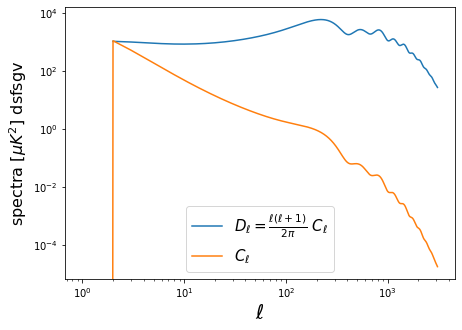

lmax =  3072


In [ ]:
fnameCLASS='cambTT00_cl_lensed.dat' #lensed Cls from CLASS in CAMB format (muK²)
l, Cl = ftau.read_Cls(fnameCLASS, plot=opt_plots)
lmax=l[-1]
print('lmax = ', lmax)

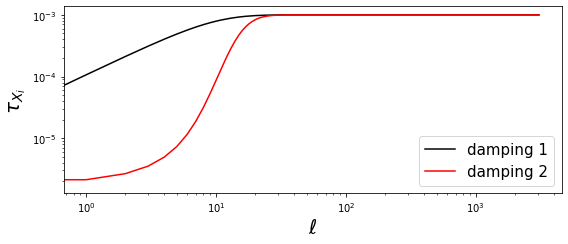

In [20]:
tau_xi=1e-3
tau_arr = ftau.get_tau_arr(tau_xi, lmax, plot=True)

lmax =  3072
nside =  1024


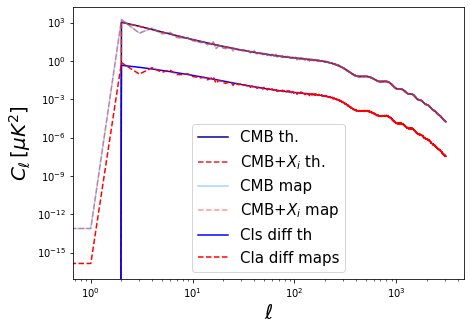

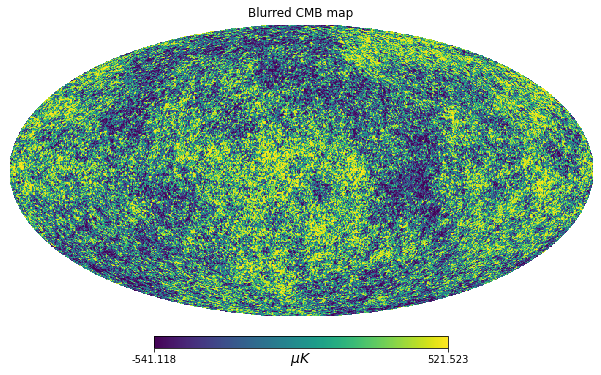

In [21]:
map_cmb, map_xi=ftau.generate_realizations(l, Cl, tau_xi, plot=opt_plots)

### Other tests


In [22]:
##CHECK: comparison with Cls from PLA: there is some small difference
if TESTS==True:
    fnamePLA='COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt' #Cls from PLA - checked that this is lensed 
    lPLA, ClPLA = read_Cls(fnamePLA, plot=False)
    lmaxPLA=lPLA[-1]
    print('lmax CLASS = ', lmax, '\tlmax PLA = ', lmaxPLA )

    diff_Cls=Cl[:lmaxPLA+1]-ClPLA[:lmaxPLA+1]
    print('(min,max) diff Cls CLASS-PLA: ', np.min(diff_Cls), np.max(diff_Cls))
    plt.figure(figsize=(7,5))
    plt.plot(l, Cl, label=r'CLASS', color='blue')
    plt.plot(lPLA, ClPLA, label=r'PLA', color='red', ls='--')
    plt.plot(lPLA, diff_Cls, label=r'difference', color='k')
    plt.xscale('log')
    plt.yscale('symlog', linthresh=1e-4)
    plt.xlabel(r'$\ell$', fontsize=20)
    plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=20)
    plt.legend(fontsize=15)
    plt.show() 

In [23]:
## generate N realizations and average them
if TESTS==True:
    N=100
    lmax=int(l[-1])
    Cl_list=[]
    for i in range(N):
        alm_realization = hp.synalm(Cl, lmax=lmax)  #add l=0, l=1
        Cl_realization=hp.alm2cl(alm_realization)
        #Cl_realization=Cl_realization[2:]
        #Cl_realization=Cl_realization[:-2]
        Cl_list.append(Cl_realization)
    Cl_list=np.array(Cl_list)

    Cl_avg=np.zeros(len(Cl)) #average realizations
    for j in range(len(l)):
        Cl_avg[j]=np.sum(Cl_list.T[j])/N

In [24]:
#PLOT
if TESTS==True:
    plt.figure(figsize=(8,6))
    plt.plot(l, normCl*Cl, color='k', label='th. (CLASS)')
    plt.plot(l, normCl*Cl_avg, color='red', label=str(N)+' realizations average')
    plt.plot(l, normCl*Cl_list[0], color='gray', lw=1., label='1st realization', zorder=0, alpha=0.3)
    plt.xscale('log')
    #plt.yscale('log')
    plt.xlabel(r'$\ell$', fontsize=20)
    plt.ylabel(r'$\ell(\ell+1)/2\pi\,\,C_\ell\,[\mu K^2]$', fontsize=20) 
    plt.legend(fontsize=15)
    plt.show()


### Read beam

In [25]:
map_beam, v1c = fbeams.read_beam(freq, printtext=True)

Beam file:  beams_070_2247339.fits
Nside =  1024

Beam center:
- center pixel idx =  2247339
- center lonlat (phi,theta) =  (60.029296875, 39.98433353062975)
- center vector = [0.38277074 0.66376194 0.64257812]
Normalization factor =  0.9910121240031213
Normalized beam integral =  0.9999999999999998


In [26]:
nside1=hp.get_nside(map_cmb) 
nside2=hp.get_nside(map_beam)
if nside1!=nside2: 
    print('\nNside of beam map and CMB realizations do not coincide')
    nside=min(nside1, nside2)
    print('downgrading to lower resolution map: nside = ', nside )
    map_xi=hp.pixelfunc.ud_grade(map_xi, nside)
    map_beam_ini=hp.pixelfunc.ud_grade(map_beam_ini, nside)
elif nside1==nside2: 
    nside=nside1 #if they are the same, set common nside
    print('\nchecked that the two maps have the same Nside=', nside)



checked that the two maps have the same Nside= 1024


l=0	 4pi*Cl=: 0.999999999998238 	 Cl = 0.07957747154580745
l=1	 4pi*Cl=: 0.9999944116785758 	 Cl = 0.07957702684145855
l=2	 4pi*Cl=: 0.9999832351607852 	 Cl = 0.07957613744243208
l=3	 4pi*Cl=: 0.9999664706486598 	 Cl = 0.07957480336494545
l=4	 4pi*Cl=: 0.9999441184574955 	 Cl = 0.07957302463408908
max map_beam =  59100.12206855254 	max rad profile =  59910.23888714125


/home/evanetti/BEAMS/functions_beams.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


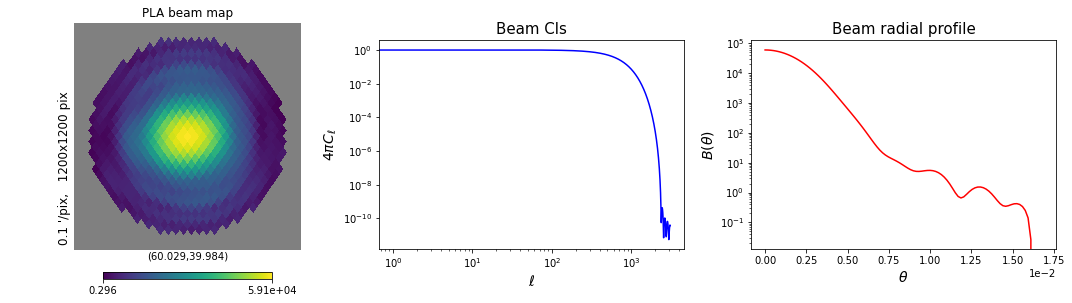

In [27]:
if opt_plots==True:
    fbeams.plot_beam(map_beam, v1c)

## Convolve disk

In [28]:
importlib.reload(frot)

#convolution settings 
phic, thetac=10., 45.  #where to convolve
rad=3. #radius or area to convolve, in degrees
imsize=3000 #size of image


checked that the two maps have the same Nside= 1024

beam dimension (rad) =  0.015248735030958454
724 pixels used for interpolation

beam dimension (rad) =  0.015248735030958454
724 pixels used for interpolation

nº of pixels to convolve: 8623
start convolution...
convolution ended

maps centered at (phi, theta) = (10.0,45.0)

(min,max) original T field: (-339.46 , 331.00)
(min,max) convolved T field: (-267.49 , 275.38)
(min,max) difference: (-104.14 , 122.77)


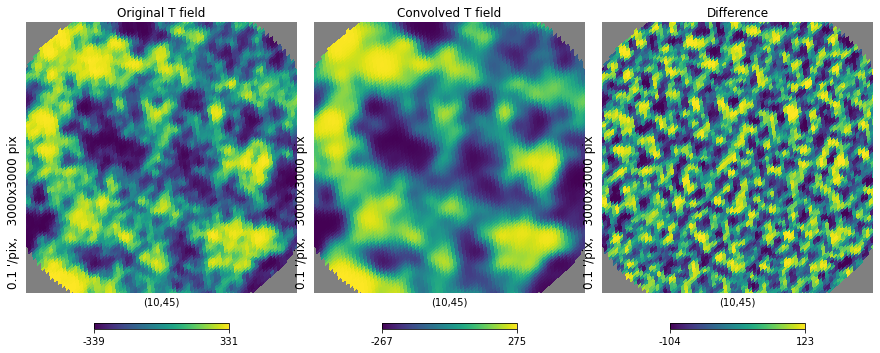

In [ ]:
#full convolution function + plots
map_xi_conv=frot.convolve_disk(map_xi, map_beam, v1c, phic, thetac, angradius_conv=rad, size=imsize )

In [30]:
#get quantities for beam rotation and convolution
v2c=hp.pixelfunc.ang2vec(phic, thetac, lonlat=True)
nside, R1, angdistR, interpolator0, pixArea_rad, idpix_disk, v_disk = frot.get_convolution_quantities(map_xi, map_beam, v1c, v2c, rad)


npix_disk=len(idpix_disk)
print('\nnº of pixels to convolve:', len(idpix_disk))



checked that the two maps have the same Nside= 1024

beam dimension (rad) =  0.015248735030958454
724 pixels used for interpolation

beam dimension (rad) =  0.015248735030958454
724 pixels used for interpolation

nº of pixels to convolve: 8623


In [31]:
# perform convolution ---> use this to test different types of convolution functions
T_convolved=np.zeros(npix_disk)
for i in range(npix_disk):
    T_convolved[i]=frot.convolve_1pix(R1, v_disk[i], interpolator0, nside, angdistR, pixArea_rad, map_xi ) 


maps centered at (phi, theta) = (10.0,45.0)

(min,max) original T field: (-339.46 , 331.00)
(min,max) convolved T field: (-267.49 , 275.38)
(min,max) difference: (-104.14 , 122.77)


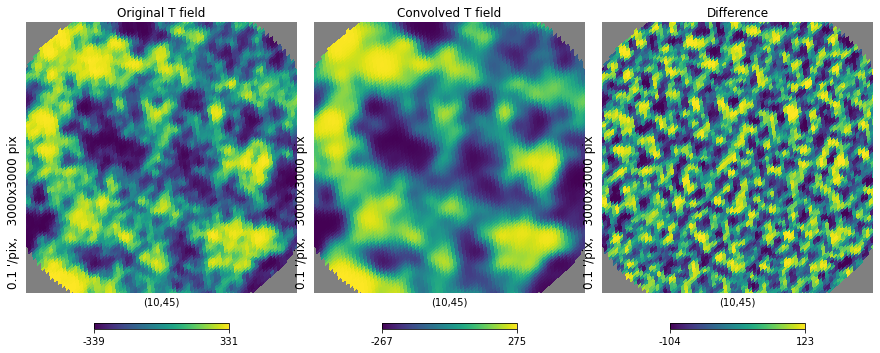

1

In [32]:
#create map
npix=12*nside**2 #get beam map 2
map_conv2=np.zeros(npix)
map_conv2[idpix_disk]=T_convolved 

frot.compare_map_area(map_xi, map_conv2, v2c, size=imsize)

In [33]:
if TESTS==True:  #check that convolutions are the same
    diff_conv=map_xi_conv-map_conv2
    print('(min,max) diff between convolved maps', np.min(diff_conv), np.max(diff_conv))


In [34]:
if TESTS==True: #check that convolution loop is the same
    T_convolved2=np.zeros(npix_disk)
    T_convolved2=[frot.convolve_1pix(R1, v, interpolator0, nside, angdistR, pixArea_rad, map_xi )  for v in v2c_array]
    T_convolved2=np.array(T_convolved2)  #checked that it's the exaxt same as using for-loop

    diff_=T_convolved-T_convolved2
    print('(min,max) fidd between convolved T', np.min(diff_), np.max(diff_))

## Convolution with a symmetric beam

same convolution but with a symmetric beam

724  pixels inside defined beam radius
symmetric beam max:  59910.238887141255
original beam max:  59100.12206855254

checked that the two maps have the same Nside= 1024

beam dimension (rad) =  0.015396362332506299
743 pixels used for interpolation

beam dimension (rad) =  0.015396362332506299
743 pixels used for interpolation

nº of pixels to convolve: 8623
start convolution...
convolution ended

maps centered at (phi, theta) = (10.0,45.0)

(min,max) original T field: (-339.46 , 331.00)
(min,max) convolved T field: (-268.88 , 275.62)
(min,max) difference: (-105.18 , 123.28)


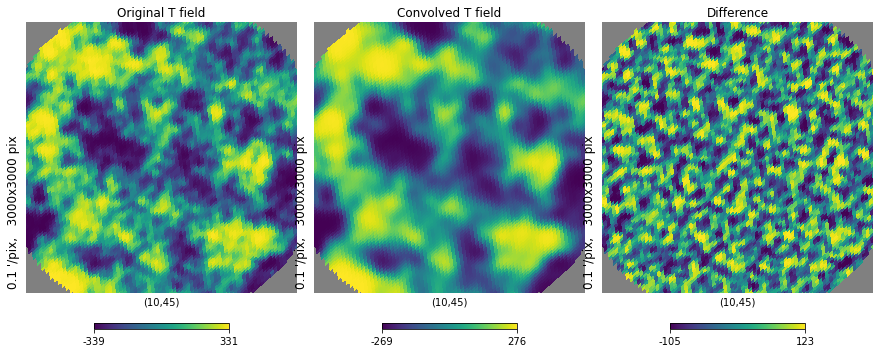

In [35]:
map_beam_symm = fbeams.symmetrize_beam(map_beam, v1c, plot=False)
map_xi_conv_symm=frot.convolve_disk(map_xi, map_beam_symm, v1c, phic, thetac, angradius_conv=rad, size=imsize )


maps centered at (phi, theta) = (10.0,45.0)

(min,max) original T field: (-267.49 , 275.38)
(min,max) convolved T field: (-268.88 , 275.62)
(min,max) difference: (-6.48 , 6.80)


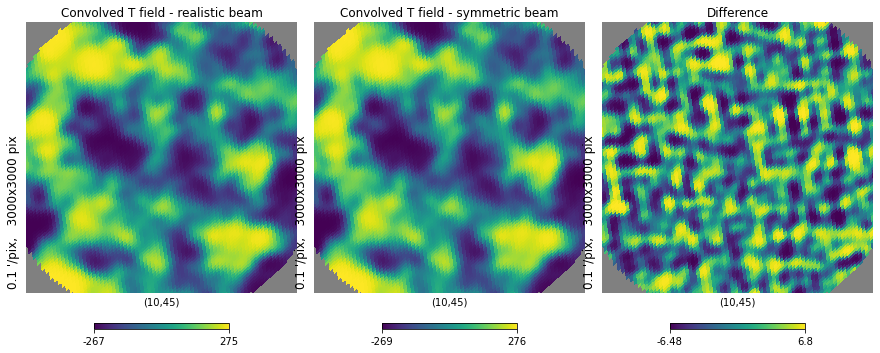

1

In [36]:
diff_conv_symm=map_xi_conv-map_xi_conv_symm
titles=['Convolved T field - realistic beam','Convolved T field - symmetric beam']
frot.compare_map_area(map_xi_conv, map_xi_conv_symm, v2c, size=imsize, titles=titles)  

In [37]:
#### Convolve with symmetric beam in harmonic space ---> plot difference map
Cls_beam=hp.anafast(map_beam, lmax=lmax)*4*np.pi
map_conv_hs = hp.sphtfunc.smoothing(map_xi, beam_window=np.sqrt(Cls_beam), lmax=lmax)


maps centered at (phi, theta) = (10.0,45.0)

(min,max) original T field: (-268.87 , 275.62)
(min,max) convolved T field: (-268.88 , 275.62)
(min,max) difference: (-0.02 , 0.01)


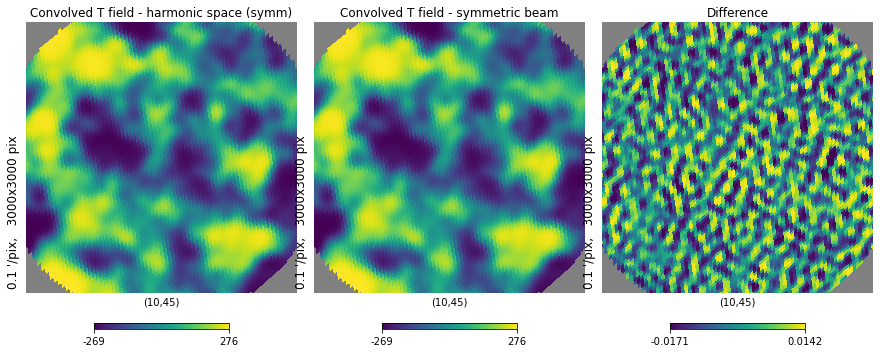

1

In [38]:
######### TEST rotation and convolution CODE PRECISION ########
titles=['Convolved T field - harmonic space (symm)', 'Convolved T field - symmetric beam']

#xsize=n pixels per side
#reso=seize of each image pixel --> decresed to get more resolution 
#compute:  ang_size=reso*xsize/60  #in degrees

frot.compare_map_area(map_conv_hs,map_xi_conv_symm, v2c, size=3000, titles=titles)
#difference = between harmonic-space convolution and real-space convolution with a symmetric beam. --> difference should be due to pixelization effects / numerical from beam rotation code


maps centered at (phi, theta) = (10.0,45.0)

(min,max) original T field: (-268.87 , 275.62)
(min,max) convolved T field: (-267.49 , 275.38)
(min,max) difference: (-6.80 , 6.48)


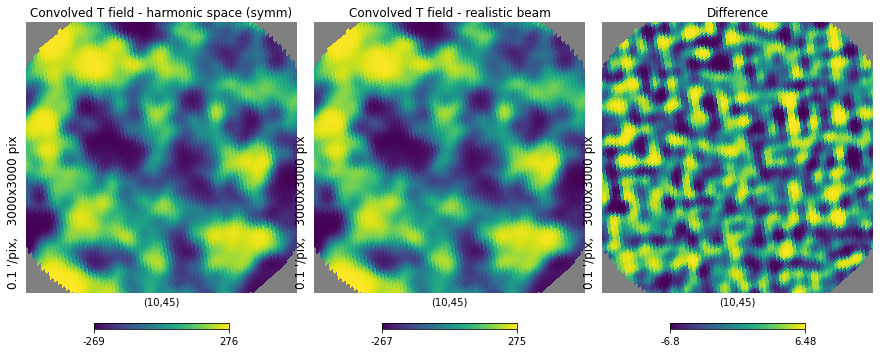

1

In [ ]:
## see diff between map convolved with realistic beam and map convolved in harmonic space (symm)
titles=['Convolved T field - harmonic space (symm)', 'Convolved T field - realistic beam']



frot.compare_map_area(map_conv_hs, map_xi_conv, v2c, size=3000, titles=titles)


##RESULTS: diff between convolution with a symmetric beam in real and harmonic space is \sim 10^-2, 
#          diff between convolution with a realistic beam and symmetric beam (both real and harmonic space): \sim 7-8 (3 orders of magnitude lower)
# ---> code seems to work very well


#plot: diff between deconvolved map - initial th. map --> see entity of difference

#write function to set dimension of plots in a reasonable way


In [ ]:
### set scale of image: 
def set_imgsize(angsize_img, npix_side): #in degrees (check this) // Nper: pixel size in image = Nper*pixsize_ini  --> increase to get less resolution

    #compute pix dimension: 
    pixsize_img=angsize_img*60/npix_side  #reso parameter, from ang_size=reso*xsize/60  #in degrees, where reso=pixsize_img, xsize=npix_side


    pixArea_deg= hp.nside2pixarea(nside, degrees=True)
    pixsize_ini=np.sqrt(pixArea_deg)
    print('image pixels size = ', pixsize_img/pixsize_ini, 'times initial pixels')

    return pixsize_img  #reso parameter

#xsize=n pixels per side
#reso=size of each image pixel --> decresed to get more resolution 
#compute:  ang_size=reso*xsize/60  #in degrees

pixsize_img=set_imgsize(2.2*rad, 1500)

image pixels size =  3.4929551631240146 times initial pixels


In [40]:
#difference of map deconvolved with symmetric beam
#- deconvolve map - plot to check if scale is right 
#- diff with original map

In [41]:
### convolution with healpy interpolator
def convolve_1pix_hp(v2c_i, cmb_map):
    beam_idpix2_interp = hp.query_disc(nside=nside, vec=v2c_i, radius=angdistR,inclusive=False, nest=False, buff=None)   # Find pixels around destination #takes 3.6 mus --> not worth it to optimize
    v1_interp = rotation_matrix_frame(R1, v2c_i).T @ np.vstack(hp.pix2vec(nside, beam_idpix2_interp)) 
    phi_interp, theta_interp = hp.vec2ang(v1_interp.T, lonlat=True) 
    beam_interp = hp.get_interp_val(map_beam, phi_interp, theta_interp, lonlat=True)   
    return np.dot(cmb_map[beam_idpix2_interp], beam_interp) * pixArea_rad 

## Code execution time

full function (30 GHz): 71e-3 s = 0.071 s

7.17e-6 s    query_disc

12e-6 s      R.T @ v2_interp 

0.73e-6 s    rotation matrix   OK

5.57e-6 s    final dot product  OK

65.8e-3 s    RBF interpolator - 2.7e-3 s with griddata

#### Test different convolution functions
                                                    30GHz    
- optimized function with RBFI interp:              80ms
- optimized+contracted function with RBFI interp:   72ms   
- function with hp interpolation:                   0.7ms

In [ ]:
phic2_test, thetac2_test= 20, 45.   #destination coordinates
v2c_test=hp.pixelfunc.ang2vec(phic2_test, thetac2_test, lonlat=True)

%timeit  convolve_1pix(R1, v2c_test, interpolator0, nside, angdistR, pixArea_rad, map_xi ) 

NameError: name 'frequency' is not defined

In [ ]:
print(frequency)
%timeit convolve_1pix_contracted(R1, v2c_test, interpolator0, nside, angdistR, pixArea_rad, map_xi ) 

In [ ]:
print(frequency)
%timeit convolve_1pix_hp(v2c_test, map_xi) ### convolution function with healpy interpolator

In [ ]:
nside_test=np.array([2048, 1024, 512, 256, 128, 64])
npix=12*nside_test**2

for i in range(len(nside_test)):
    print(f'MAP: nside={nside_test[i]}, npix={npix[i]}')
    print(f'rot+convolutiomn: ({0.7e-3*npix[i]/(60*60):.2f} +- {0.013e-3*npix[i]/(60*60):.2f}) hours')

#### Test different function segments 

                    30GHz
- query disk        5e-6 ok
- pix2vec           0.1ms ok
- rot matrix R1     7e-6 - improved!
- vec rotation      15e-6 - improved in respect to hp rotator
- RBF interpolator  75ms  <------BOTTLENECK
- convolution product 5e-6
-----------------------------------------------
- get ang coord     0.1ms
- hp interpolator   0.2ms 



In [ ]:
phic2_test, thetac2_test= 20, 45.   #destination coordinates
v2c_test=hp.pixelfunc.ang2vec(phic2_test, thetac2_test, lonlat=True)

beam_idpix2_interp=hp.query_disc(ns 70ide=nside, vec=v2c_test, radius=angdistR, inclusive=False, nest=False, buff=None)  # get indeces of pixels around v2c
v2_interp = np.vstack(hp.pix2vec(nside, beam_idpix2_interp))
R=rotation_matrix_frame(R1, v2c_test)  
v1_interp = R.T @ v2_interp 
beam_interp = interpolator0(v1_interp.T)

phi_interp, theta_interp = hp.vec2ang(v1_interp.T, lonlat=True) 
beam_interp_hp = hp.get_interp_val(map_beam, phi_interp, theta_interp, lonlat=True)  
T_convolved_i = np.dot(map_xi[beam_idpix2_interp],beam_interp)*pixArea_rad

In [ ]:
print(frequency)

%timeit hp.query_disc(nside=nside, vec=v2c_test, radius=angdistR, inclusive=False, nest=False, buff=None)
%timeit np.vstack(hp.pix2vec(nside, beam_idpix2_interp))
%timeit rotation_matrix_frame(R1, v2c_test) 
%timeit R.T @ v2_interp 
%timeit interpolator0(v1_interp.T)

%timeit hp.vec2ang(v1_interp.T, lonlat=True) 
%timeit hp.get_interp_val(map_beam, phi_interp, theta_interp, lonlat=True)

%timeit np.dot(map_xi[beam_idpix2_interp],beam_interp)*pixArea_rad

In [ ]:
print(len(v1_interp.T))
%timeit interpolator0(v1_interp.T)

 #### Test interpolator
 
 - RBFInterpolator: 70e-3 s - works well

 - Healpy interpolator 0.5e-3 s 

 - griddata: 3e-3s - poor performance on Cls, lower on beam moments
 
 - NearestNDInterpolator: 1.5e-3 s  - result similar to griddata
 
 - LinearNDInterpolator: 0.5e-3 s   - does not work


See how well the tangent plane approximation is

In [ ]:
# kernel options: inverse_quadratic is the fastets - linear is faster but does not work - all others are slower than cubic
interpolator_cubic = RBFInterpolator(v1, beam0, kernel='cubic')
%timeit  interpolator_cubic(v1_interp.T)

interpolator_linear = RBFInterpolator(v1, beam0, kernel='linear') #faster but I remember it didn't work well on beams
%timeit  interpolator_linear(v1_interp.T)

interpolator_gauss = RBFInterpolator(v1, beam0, kernel='inverse_quadratic', epsilon=0.5) #slower
%timeit  interpolator_gauss(v1_interp.T)

In [ ]:
### TESTED ON BEAM: DOES NOT WORK or performs poorly
from scipy.interpolate import griddata  #don't know if grid
beam_interp_griddata=griddata(v1, beam0, v1_interp.T, method='nearest') #'nearest', 'cubic'
%timeit griddata(v1, beam0, v1_interp.T, method='nearest')

In [ ]:
### TESTED ON BEAM: DOES NOT WORK or performs poorly

from scipy.interpolate import NearestNDInterpolator, LinearNDInterpolator  

nearest_interp = NearestNDInterpolator(v1, beam0)
beam_interp_nearest = nearest_interp(v1_interp.T)

# Linear (can be unstable in high-D)
linear_interp = LinearNDInterpolator(v1, beam0)
beam_interp_linear = linear_interp(v1_interp.T)

%timeit nearest_interp(v1_interp.T)
%timeit linear_interp(v1_interp.T)

In [ ]:
nside_test=np.array([2048, 1024, 512, 256, 128, 64])
npix=12*nside_test**2

for i in range(len(nside_test)):
    print(f'MAP: nside={nside_test[i]}, npix={npix[i]}')
    print(f'rot+convolutiomn: ({3.6e-3*npix[i]/(60*60):.2f} +- {0.93e-3*npix[i]/(60*60):.2f}) hours')

### Parallelization trend

In [ ]:
###MPI-parallelized script

Ncores=np.array([1,2,4,8])
time=np.array([0.00304, 0.00167, 0.00108, 0.00073])
time_hours=np.array([10.49878 , 5.83308, 3.76299, 2.559])

print(f'time reduced by a factor {time[0]/time[-1]:.3f} with 8 cores')


plt.figure(figsize=(8, 5))

#plt.plot(Ncores, time, marker='o', linestyle='-', color='blue', label='Execution Time')
#plt.ylabel('Time per Iteration [s]')

plt.plot(Ncores, time_hours, marker='o', linestyle='-', color='blue', label='Execution Time')
plt.ylabel('Time per map [hours]')

plt.xlabel('Number of Cores')
plt.title('Execution Time vs. Number of Cores')
plt.grid(True)
plt.xticks(Ncores)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
sin_alcol=np.array([0.81, 0.81, 0.81, 0.81, 0.93, 1.04, 1.21, 2.16, 1.03])
alcol=np.array([11.88, 11.88, 0.69, 2.72, 2.72, 1.66, 2.72, 2.32, 2.72, 2.72, 3.72, 1.66, 2.19, 2.19, 2.19, 4.59, 2.19, 6.99, 10.32, 4.59, 2.51, 2.19, 2.68,3.22])
common=np.array([1.78, 1.78, 1.24, 1.04, 1.69, 0.36, 1.66, 1.61, 1.02, 3.92,1.09, 1.15, 1.13,1.99,1.48, 1.21,0.89,0.89,2.07, 0.98, 1.35, 1.99, 0.55, 1.10 ])
dino=np.array([1.05, 1.54, 1.54, 2.33, 3.88, 2.73, 2.37, 2.18]) #checked
print('tot dino:', np.sum(dino))
print('tot alcampo', np.sum(sin_alcol)+np.sum(alcol)+np.sum(common)+1.89)
print('tot:', np.sum(dino) + np.sum(sin_alcol)+np.sum(alcol)+np.sum(common)+1.89)

Nalcol=15+2
Nsinalcol=4
Ntot=Nalcol+Nsinalcol

print(f'tot sin alcol={np.sum(sin_alcol)}')
print(f'tot alcol={np.sum(alcol)}')
print(f'tot common={np.sum(common)}')
print('\n')


print('sinalcol/person=', np.sum(sin_alcol)/Nsinalcol)
print('alcol/person=', np.sum(alcol)/Nalcol)
print('common/person=', (np.sum(common)+np.sum(dino))/Ntot)

sinalcol_person=np.sum(sin_alcol)/Nsinalcol+(np.sum(common)+np.sum(dino))/Ntot
alcol_person= np.sum(alcol)/Nalcol+(np.sum(common)+np.sum(dino))/Ntot
print('\ntotal/person sin alcol = ',sinalcol_person )
print('total/person alcol = ',alcol_person )


print('reconstructed total = ',sinalcol_person*Nsinalcol + alcol_person*Nalcol +1.89, '---> OK!')
print('what I should get back = ',sinalcol_person*(Nsinalcol-2) + alcol_person*(Nalcol-1))
print('paid by me: ', sinalcol_person*2+alcol_person)

